# CSC173 · Lecture 01 · Introduction to Deep Learning
## Session demo with TensorFlow (Keras)

Jennifer Joyce M. Montemayor · Department of Computer Science, MSU-IIT

This notebook follows the lecture, in order:

1. One perceptron by hand, then as a Keras `Dense` layer
2. Why we need non-linear activation functions
3. Our backpropagation example, checked with `tf.GradientTape`
4. Gradient descent and the learning rate
5. *Will I pass this class?* A complete Keras model
6. Exercises

**How to run:** open it in Google Colab (TensorFlow is already installed) or in Jupyter with `pip install tensorflow matplotlib`. Run the cells from top to bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.keras.utils.set_random_seed(173)   # same random numbers every run, so results are repeatable
print("TensorFlow", tf.__version__)

I0000 00:00:1791212000.911168   14618 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


I0000 00:00:1791212002.403491   14618 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


---
## 1. One perceptron

From the lecture: $\hat{y} = g(w_0 + X^T W)$ with $w_0 = 1$, $W = \begin{bmatrix}3\\-2\end{bmatrix}$ and input $X = \begin{bmatrix}-2\\4\end{bmatrix}$.

### 1a. By hand with NumPy

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w0 = 1.0                      # bias
W  = np.array([3.0, -2.0])    # weights
X  = np.array([-2.0, 4.0])    # one input example

z = w0 + X @ W                # weighted sum: 1 + (3 * -2) + (-2 * 4)
y_hat = sigmoid(z)            # non-linear activation

print("z     =", z)
print("y_hat =", y_hat)

z     = -13.0
y_hat = 2.2603242979035746e-06


`z = -13`, so the point is far on the "0" side of the line $1 + 3x_1 - 2x_2 = 0$, and the sigmoid gives a number very close to 0.

**Try it:** change `X` to `[1, 1]`. You should get $z = 2$ and $\hat{y} \approx 0.88$.

### 1b. The same perceptron as a Keras `Dense` layer

A `Dense(1)` layer *is* a perceptron. We copy our weights into it and get the same answer.

In [3]:
layer = tf.keras.layers.Dense(units=1, activation="sigmoid")
layer.build(input_shape=(None, 2))                     # 2 inputs -> creates the weights
layer.set_weights([np.array([[3.0], [-2.0]]),          # kernel W (shape 2 x 1)
                   np.array([1.0])])                   # bias w0

print("Keras output:", layer(np.array([[-2.0, 4.0]])).numpy())

Keras output: [[2.2603242e-06]]


---
## 2. Why non-linear activation functions?

We make a dataset that a straight line cannot separate (two interleaving half-moons), then train two models:

* **Linear model:** no hidden layer. Its decision boundary is a straight line.
* **Small neural network:** one hidden layer with ReLU. It can bend the boundary.

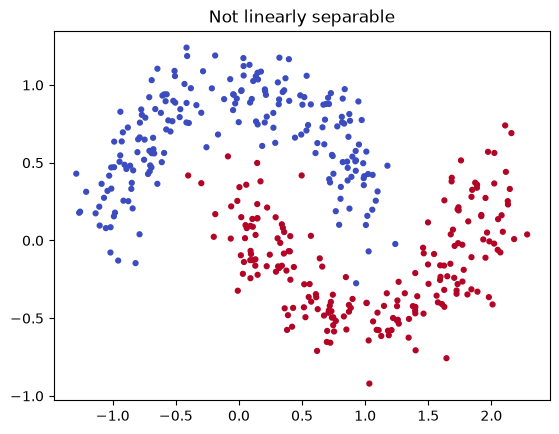

In [4]:
def make_moons(n=400, noise=0.15):
    t = np.random.rand(n // 2) * np.pi
    a = np.c_[np.cos(t), np.sin(t)]                    # upper moon -> class 0
    b = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]          # lower moon -> class 1
    X = np.vstack([a, b]) + noise * np.random.randn(n, 2)
    y = np.r_[np.zeros(n // 2), np.ones(n // 2)]
    return X.astype("float32"), y.astype("float32")

X_moons, y_moons = make_moons()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="coolwarm", s=12)
plt.title("Not linearly separable"); plt.show()

In [5]:
linear_model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(1, activation="sigmoid"),     # a single perceptron
])

nonlinear_model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),       # hidden layer with a non-linearity
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

for m in (linear_model, nonlinear_model):
    m.compile(optimizer=tf.keras.optimizers.Adam(0.05), loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(X_moons, y_moons, epochs=150, verbose=0)

print("Linear model accuracy:     %.2f" % linear_model.evaluate(X_moons, y_moons, verbose=0)[1])
print("Neural network accuracy:   %.2f" % nonlinear_model.evaluate(X_moons, y_moons, verbose=0)[1])

Linear model accuracy:     0.92
Neural network accuracy:   1.00


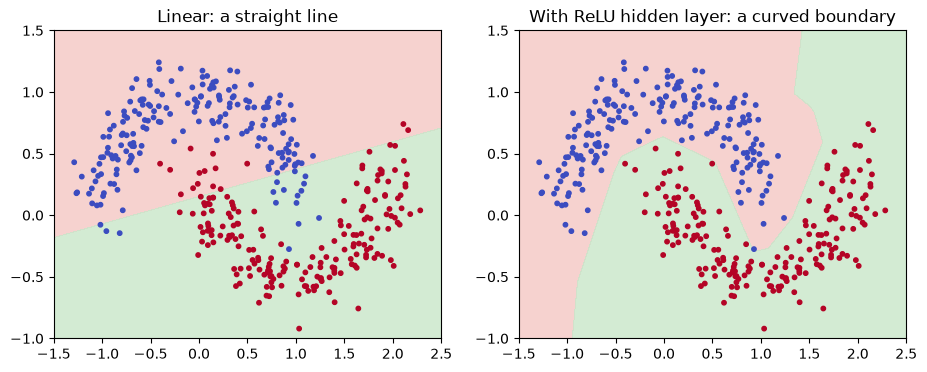

In [6]:
def plot_boundary(model, X, y, ax, title):
    xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype("float32")
    p = model.predict(grid, verbose=0).reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=[0, 0.5, 1], colors=["#f4c7c3", "#c8e6c9"], alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=10)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_boundary(linear_model, X_moons, y_moons, axes[0], "Linear: a straight line")
plot_boundary(nonlinear_model, X_moons, y_moons, axes[1], "With ReLU hidden layer: a curved boundary")
plt.show()

**Discuss:** replace `activation="relu"` with `activation=None` (or `"linear"`) in the hidden layer and re-run. Why does accuracy drop back to the linear model's level?

---
## 3. Our backpropagation example, checked by TensorFlow

The network from the lecture: inputs $i_1 = 0.05$, $i_2 = 0.10$; targets $o_1 = 0.01$, $o_2 = 0.99$; sigmoid everywhere; error $E = \tfrac12\sum(\text{actual} - \text{predicted})^2$; learning rate $0.3$.

`tf.GradientTape` records the forward pass and then computes every $\partial E / \partial w$ for us. This is backpropagation, done automatically.

In [7]:
i = tf.constant([0.05, 0.10])
target = tf.constant([0.01, 0.99])

w1, w2, w3, w4 = [tf.Variable(v) for v in (0.15, 0.20, 0.25, 0.30)]
w5, w6, w7, w8 = [tf.Variable(v) for v in (0.40, 0.45, 0.50, 0.55)]
b1, b2, b3, b4 = 0.35, 0.35, 0.60, 0.60

with tf.GradientTape() as tape:
    # forward propagation (same equations as the slides)
    z1 = i[0] * w1 + i[1] * w3 + b1;  h1 = tf.sigmoid(z1)
    z2 = i[0] * w2 + i[1] * w4 + b2;  h2 = tf.sigmoid(z2)
    z3 = h1 * w5 + h2 * w7 + b3;      o1 = tf.sigmoid(z3)
    z4 = h1 * w6 + h2 * w8 + b4;      o2 = tf.sigmoid(z4)
    E = 0.5 * ((target[0] - o1) ** 2 + (target[1] - o2) ** 2)

print(f"h1 = {h1.numpy():.4f}   h2 = {h2.numpy():.4f}")
print(f"o1 = {o1.numpy():.4f}   o2 = {o2.numpy():.4f}")
print(f"E  = {E.numpy():.5f}")

dE_dw5, dE_dw1 = tape.gradient(E, [w5, w1])
lr = 0.3
print(f"\ndE/dw5 = {dE_dw5.numpy():.4f}   ->  new w5 = 0.40 - 0.3 * {dE_dw5.numpy():.4f} = {0.40 - lr * dE_dw5.numpy():.4f}")
print(f"dE/dw1 = {dE_dw1.numpy():.6f} ->  new w1 = 0.15 - 0.3 * {dE_dw1.numpy():.6f} = {0.15 - lr * dE_dw1.numpy():.4f}")

h1 = 0.5945   h2 = 0.5963
o1 = 0.7569   o2 = 0.7677
E  = 0.30366

dE/dw5 = 0.0817   ->  new w5 = 0.40 - 0.3 * 0.0817 = 0.3755
dE/dw1 = 0.000448 ->  new w1 = 0.15 - 0.3 * 0.000448 = 0.1499


These match the slides (TensorFlow keeps more decimals, so the 4th decimal can differ by 1): $\partial E/\partial w_5 \approx 0.0816$ (new $w_5 \approx 0.3755$) and $\partial E/\partial w_1 \approx 0.00045$ (new $w_1 \approx 0.1499$).

Now let TensorFlow repeat the update many times and watch the error fall. This loop is gradient descent: **forward pass → loss → gradients → update**.

error after 1 step: 0.30366   after 2000 steps: 0.000881
outputs now: o1 = 0.040 (target 0.01), o2 = 0.961 (target 0.99)


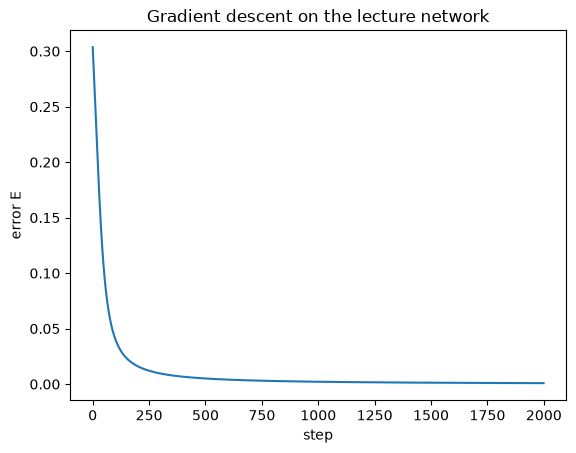

In [8]:
weights = [w1, w2, w3, w4, w5, w6, w7, w8]
optimizer = tf.keras.optimizers.SGD(learning_rate=0.3)
history = []

for step in range(2000):
    with tf.GradientTape() as tape:
        h1 = tf.sigmoid(i[0] * w1 + i[1] * w3 + b1)
        h2 = tf.sigmoid(i[0] * w2 + i[1] * w4 + b2)
        o1 = tf.sigmoid(h1 * w5 + h2 * w7 + b3)
        o2 = tf.sigmoid(h1 * w6 + h2 * w8 + b4)
        E = 0.5 * ((target[0] - o1) ** 2 + (target[1] - o2) ** 2)
    grads = tape.gradient(E, weights)                 # backpropagation
    optimizer.apply_gradients(zip(grads, weights))    # W <- W - lr * dE/dW
    history.append(E.numpy())

print(f"error after 1 step: {history[0]:.5f}   after 2000 steps: {history[-1]:.6f}")
print(f"outputs now: o1 = {o1.numpy():.3f} (target 0.01), o2 = {o2.numpy():.3f} (target 0.99)")
plt.plot(history); plt.xlabel("step"); plt.ylabel("error E"); plt.title("Gradient descent on the lecture network"); plt.show()

---
## 4. Gradient descent and the learning rate

The update rule is $W \leftarrow W - \eta \,\dfrac{\partial J}{\partial W}$. Here we minimise the simple function $f(x) = (x - 2)^2$, whose slope is $f'(x) = 2(x - 2)$, starting from $x = 9$ with three learning rates.

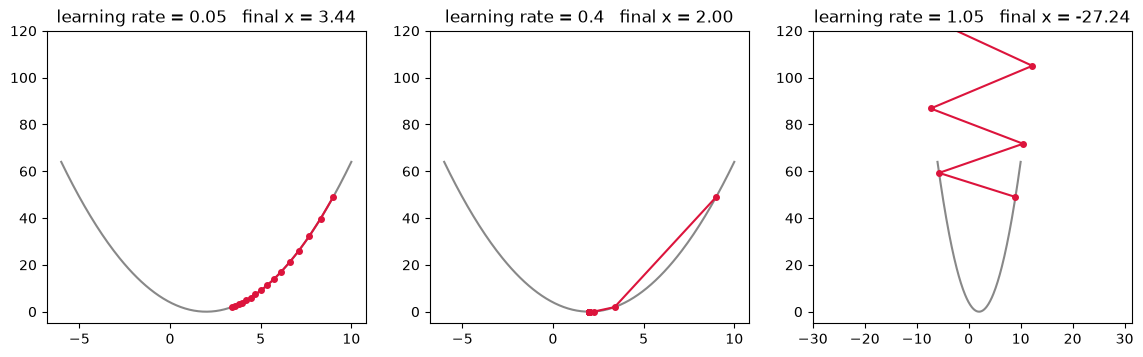

In [9]:
def gradient_descent(lr, x=9.0, steps=15):
    path = [x]
    for _ in range(steps):
        grad = 2 * (x - 2)       # derivative of (x - 2)^2
        x = x - lr * grad        # the update rule
        path.append(x)
    return np.array(path)

xs = np.linspace(-6, 10, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, lr in zip(axes, [0.05, 0.4, 1.05]):
    p = gradient_descent(lr)
    ax.plot(xs, (xs - 2) ** 2, color="#888")
    ax.plot(p, (p - 2) ** 2, "o-", color="crimson", ms=4)
    ax.set_ylim(-5, 120); ax.set_title(f"learning rate = {lr}   final x = {p[-1]:.2f}")
plt.show()

* **0.05 (too small):** slow, still far from the minimum $x = 2$ after 15 steps.
* **0.4 (good):** reaches the minimum quickly.
* **1.05 (too big):** each step overshoots further and the method diverges.

---
## 5. Will I pass this class?

Features: $x_1$ = activities and assignments passed (0–10), $x_2$ = hours spent on the final project (0–10). Label: 1 = pass, 0 = fail.

> The data below is **synthetic** (generated for the demo), not real student records.

students: 200   passed: 107   failed: 93


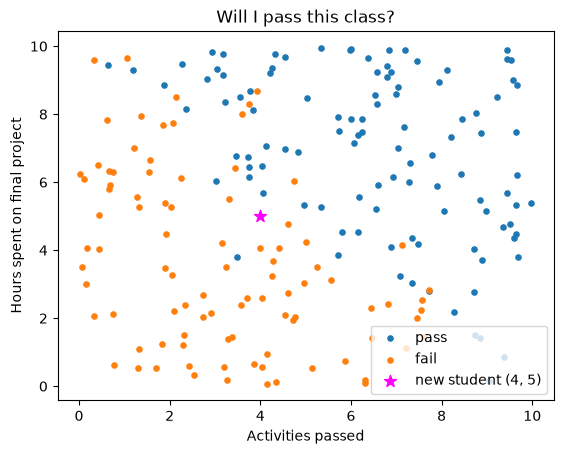

In [10]:
n = 200
activities = np.random.uniform(0, 10, n)
hours      = np.random.uniform(0, 10, n)
score = 0.6 * activities + 0.5 * hours + np.random.normal(0, 1.0, n)   # hidden "true" rule plus noise
passed = (score > 5.5).astype("float32")

X = np.c_[activities, hours].astype("float32")
y = passed
print("students:", n, "  passed:", int(y.sum()), "  failed:", int(n - y.sum()))

plt.scatter(activities[y == 1], hours[y == 1], label="pass", s=14)
plt.scatter(activities[y == 0], hours[y == 0], label="fail", s=14)
plt.scatter([4], [5], c="magenta", s=80, marker="*", label="new student (4, 5)")
plt.xlabel("Activities passed"); plt.ylabel("Hours spent on final project"); plt.legend(); plt.title("Will I pass this class?")
plt.show()

### Split the data

We keep 25% of the students aside as a **test set**. The model never trains on them, so they tell us how well it works on new students.

In [11]:
idx = np.random.permutation(n)
train, test = idx[:150], idx[150:]
X_train, y_train, X_test, y_test = X[train], y[train], X[test], y[test]

### Build, compile, train

Exactly the network from the slides: 2 inputs → 3 hidden units → 1 output.

In [12]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),                      # x1, x2
    tf.keras.layers.Normalization(),                 # rescale inputs to mean 0, std 1 (helps training)
    tf.keras.layers.Dense(3, activation="sigmoid"),  # hidden layer: z1, z2, z3
    tf.keras.layers.Dense(1, activation="sigmoid"),  # output: probability of passing
])
model.layers[0].adapt(X_train)                      # learn the mean and std from the training data
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 2)              │             5 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18 (76.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 5 (24.00 B)

Count the trainable parameters: `Dense(3)` has $2 \times 3 + 3 = 9$, `Dense(1)` has $3 \times 1 + 1 = 4$, so **13** in total. (The `Normalization` layer's mean and variance are not trained by gradient descent.)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
    loss="binary_crossentropy",          # pass/fail -> cross-entropy
    metrics=["accuracy"],
)

before = model.predict(np.array([[4.0, 5.0]]), verbose=0)[0, 0]
history = model.fit(X_train, y_train, epochs=200, batch_size=16,
                    validation_data=(X_test, y_test), verbose=0)
after = model.predict(np.array([[4.0, 5.0]]), verbose=0)[0, 0]

print(f"New student (4, 5): before training {before:.2f}, after training {after:.2f}")
print("Test accuracy: %.2f" % model.evaluate(X_test, y_test, verbose=0)[1])

New student (4, 5): before training 0.41, after training 0.21
Test accuracy: 0.86


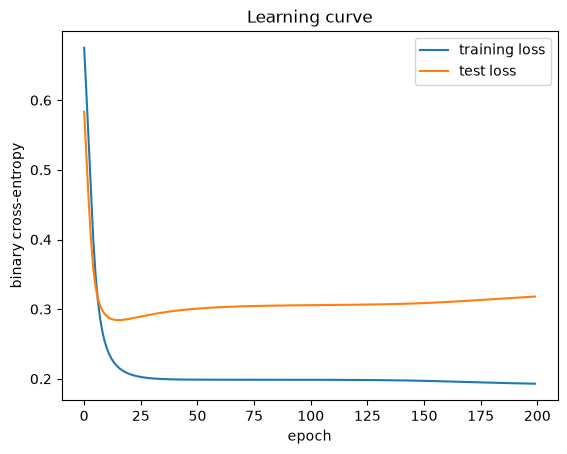

In [14]:
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.xlabel("epoch"); plt.ylabel("binary cross-entropy"); plt.legend(); plt.title("Learning curve")
plt.show()

### Mean squared error vs cross-entropy for one wrong prediction

The slide example: the model predicts 0.1, the student actually passed (1.0).

In [15]:
y_true, y_pred = np.array([1.0]), np.array([0.1])
print("MSE:          ", tf.keras.losses.MeanSquaredError()(y_true, y_pred).numpy())
print("Cross-entropy:", tf.keras.losses.BinaryCrossentropy()(y_true, y_pred).numpy())

MSE:           0.80999994
Cross-entropy: 2.3025851


### Effect of the learning rate on training

Same model, three learning rates. Watch the loss curves.

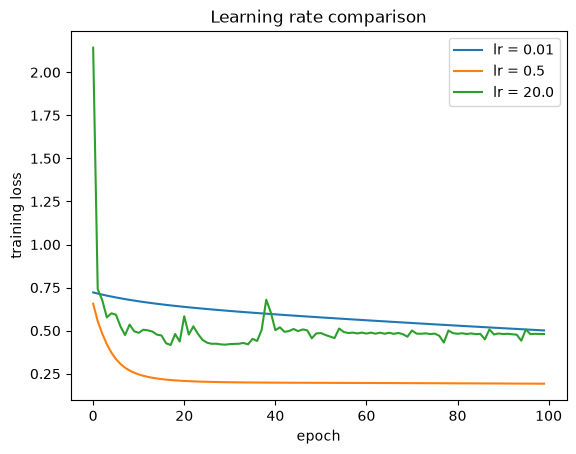

In [16]:
def build():
    m = tf.keras.Sequential([
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Normalization(),
        tf.keras.layers.Dense(3, activation="sigmoid"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    m.layers[0].adapt(X_train)
    return m

for lr in [0.01, 0.5, 20.0]:
    tf.keras.utils.set_random_seed(173)
    m = build()
    m.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr), loss="binary_crossentropy")
    h = m.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)
    plt.plot(h.history["loss"], label=f"lr = {lr}")
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.legend(); plt.title("Learning rate comparison")
plt.show()

---
## 6. Exercises

1. **Perceptron:** in section 1, find an input $X$ that gives exactly $\hat{y} = 0.5$. (Hint: it must lie on the line $1 + 3x_1 - 2x_2 = 0$.)
2. **Activations:** in section 5, change the hidden activation from `"sigmoid"` to `"relu"`. Does training get faster?
3. **Batch size:** train with `batch_size=1` (stochastic), `16` (mini-batch) and `150` (full batch). Compare the loss curves and the time taken.
4. **Network size:** try 1, 3 and 32 hidden units. Compare training accuracy with test accuracy. What do you notice with 32?
5. **Loss:** change the loss to `"mse"` and compare the learning curve with cross-entropy.
6. **Backprop by hand:** using section 3, compute $\partial E / \partial w_6$ on paper, then check it with `tape.gradient(E, w6)`.